#### Fraser, A.D. and Massom, R. (2020) Circum-Antarctic landfast sea ice extent, 2000-2018, Ver. 2.2, Australian Antarctic Data Centre - doi:10.26179/5d267d1ceb60c, Accessed: 2026-01-04

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import colorcet as cc
import os
from pyproj import Transformer

# Compute data
#### Do this for each year in order so as to write extentents into extents.txt and evanescent_extents.txt. Extents from 2019 - 2024 were computed in QGIS and saved in the area_bb_{year}.csv files. Storm index was computed in DataFile.ipynb.

In [2]:
year = 2000
# Change this path to where you've saved the Fraser & Massom, 2020, dataset. You can download it from https://data.aad.gov.au/metadata/AAS_4116_Fraser_fastice_circumantarctic.
ds = xr.open_mfdataset("../../Fraser/AAS_4116_Fraser_fastice_circumantarctic/fastice_v2_2/FastIce_70_"+str(year)+".nc", combine="by_coords", data_vars="minimal", coords="minimal", compat="override")
ds

<xarray.Dataset> Size: 952MB
Dimensions:               (X: 5625, Y: 4700, time: 20)
Coordinates:
  * time                  (time) datetime64[ns] 160B 2000-03-01 ... 2000-12-11
Dimensions without coordinates: X, Y
Data variables:
    x                     (X) float64 45kB dask.array<chunksize=(5625,), meta=np.ndarray>
    y                     (Y) float64 38kB dask.array<chunksize=(4700,), meta=np.ndarray>
    latitude              (Y, X) float32 106MB dask.array<chunksize=(4700, 5625), meta=np.ndarray>
    longitude             (Y, X) float32 106MB dask.array<chunksize=(4700, 5625), meta=np.ndarray>
    area                  (Y, X) float64 212MB dask.array<chunksize=(4700, 5625), meta=np.ndarray>
    date_alt              (time) int32 80B dask.array<chunksize=(20,), meta=np.ndarray>
    Fast_Ice_Time_series  (time, Y, X) int8 529MB dask.array<chunksize=(3, 784, 938), meta=np.ndarray>
Attributes:
    title:        Fast ice time series
    institution:  Institute for Marine and Antarctic Studies, University of T...
    source:       MODIS 15-day composite images and automated edge detection
    history:      Version 2.2
    references:   Fraser et al., 2020 (Earth System Science Data, submitted)
    comment:      This is the lat_ts=-70 version of the data - year 2000
    contact:      Alex Fraser (adfraser@utas.edu.au)
    Conventions:  CF-1.7

## Add ice-ages

In [3]:
ice = ds.Fast_Ice_Time_series.compute()
time = ds.time.compute()
last = ice.isel(time=-1)

fast_ice = last.isin([4, 5, 6])

ice_rev = ice.isel(time=slice(None, None, -1))
zero_rev = ice_rev == 0
last_zero_rev_idx = zero_rev.argmax(dim="time")
had_zero = zero_rev.any(dim="time")
last_zero_idx = (ice.sizes["time"] - 1) - last_zero_rev_idx

formation_date = xr.full_like(last, fill_value=np.datetime64("NaT"), dtype="datetime64[ns]")
formation_date = formation_date.where(~(fast_ice & had_zero), time.isel(time=last_zero_idx))
multi_year = fast_ice & ~had_zero
static_type = last.where(last.isin([1, 2, 3]))

fd = formation_date
day = fd.dt.day
month = fd.dt.month
formation_date_int = xr.full_like(day, -1, dtype=np.int16)
formation_date_int = formation_date_int.where(~(day <= 2), (month - 1) * 2)
formation_date_int = formation_date_int.where(~((day >= 11) & (day <= 17)), (month - 1) * 2 + 1)
formation_date_int = formation_date_int.where(~(day >= 26), ((month - 1) * 2 + 2) % 24)
formation_date_int = formation_date_int.where(fd.notnull())

ds = ds.assign(
    formation_date=formation_date,
    multi_year_fast_ice=multi_year,
    static_surface_type=static_type,
    formation_date_int=formation_date_int
)

## Add extents (within bounding box)

In [4]:
bounding_lat_min, bounding_lat_max = -78.1, -77.46
bounding_lon_min, bounding_lon_max = 163.4, 167.0

In [5]:
# Total area in December
fi_december = ds.Fast_Ice_Time_series.isel(time=-1)
spatial_mask = ((ds.latitude >= bounding_lat_min) & (ds.latitude <= bounding_lat_max) & (ds.longitude >= bounding_lon_min) & (ds.longitude <= bounding_lon_max))
value_mask = fi_december.isin([4, 5, 6])
mask = spatial_mask & value_mask
count = ds.area.where(mask).sum().compute().values
print(count)

2276.8737310628712


In [6]:
masked_area = ds.area.where(spatial_mask, 0)

evanescent_mask = ds.Fast_Ice_Time_series.isin([4, 5, 6])
evanescent_extent = xr.dot(evanescent_mask, masked_area, dims=("Y", "X"))

init_extent = (ds.multi_year_fast_ice * masked_area).sum(dim=("Y", "X"))
new_extent_mask = (ds.formation_date_int.expand_dims(time=ds.time) == xr.DataArray(np.arange(ds.dims["time"]), dims="time", coords={"time": ds.time}))
new_extent = xr.dot(new_extent_mask, masked_area, dims=("Y", "X"))
# Cumulative extent
extent = init_extent + new_extent.shift(time=1, fill_value=0).cumsum(dim="time")

ds = ds.assign(evanescent_extent=evanescent_extent, extent=extent)
ds

C:\Users\Homo Naledi\AppData\Local\Temp\ipykernel_6476\2105413182.py:7: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  new_extent_mask = (ds.formation_date_int.expand_dims(time=ds.time) == xr.DataArray(np.arange(ds.dims["time"]), dims="time", coords={"time": ds.time}))


<xarray.Dataset> Size: 2GB
Dimensions:               (X: 5625, Y: 4700, time: 20)
Coordinates:
  * time                  (time) datetime64[ns] 160B 2000-03-01 ... 2000-12-11
Dimensions without coordinates: X, Y
Data variables: (12/13)
    x                     (X) float64 45kB dask.array<chunksize=(5625,), meta=np.ndarray>
    y                     (Y) float64 38kB dask.array<chunksize=(4700,), meta=np.ndarray>
    latitude              (Y, X) float32 106MB dask.array<chunksize=(4700, 5625), meta=np.ndarray>
    longitude             (Y, X) float32 106MB dask.array<chunksize=(4700, 5625), meta=np.ndarray>
    area                  (Y, X) float64 212MB dask.array<chunksize=(4700, 5625), meta=np.ndarray>
    date_alt              (time) int32 80B dask.array<chunksize=(20,), meta=np.ndarray>
    ...                    ...
    formation_date        (Y, X) datetime64[ns] 212MB NaT NaT NaT ... NaT NaT
    multi_year_fast_ice   (Y, X) bool 26MB False False False ... False False
    static_surface_type   (Y, X) float32 106MB nan nan nan nan ... nan nan nan
    formation_date_int    (Y, X) float64 212MB nan nan nan nan ... nan nan nan
    evanescent_extent     (time) float64 160B dask.array<chunksize=(3,), meta=np.ndarray>
    extent                (time) float64 160B dask.array<chunksize=(20,), meta=np.ndarray>
Attributes:
    title:        Fast ice time series
    institution:  Institute for Marine and Antarctic Studies, University of T...
    source:       MODIS 15-day composite images and automated edge detection
    history:      Version 2.2
    references:   Fraser et al., 2020 (Earth System Science Data, submitted)
    comment:      This is the lat_ts=-70 version of the data - year 2000
    contact:      Alex Fraser (adfraser@utas.edu.au)
    Conventions:  CF-1.7

In [7]:
## Convert array to a string of space-separated values
#ev_vals = " ".join(map(str, ds.evanescent_extent.values.flatten()))
#ext_vals = " ".join(map(str, ds.extent.values.flatten()))
#
#with open("../Data/fraser/evanescent_extents.txt", "a") as f:
#    f.write(f"{year}\t{ev_vals}\n")
#
#with open("../Data/fraser/extents.txt", "a") as f:
#    f.write(f"{year}\t{ext_vals}\n")

# Plots

In [8]:
# Storm index from si_file.csv
df_si = pd.read_csv('../Data/si_file.csv')
df_si = df_si[['DateTime', 'SB_SI']]
df_si["DateTime"] = pd.to_datetime(df_si["DateTime"], format="%Y-%m-%d")
df_si.index = df_si['DateTime']
df_si['month_day'] = df_si.index.strftime('%m-%d')
df_si['year'] = df_si.index.year
df_si = pd.concat([df_si.pivot(index='month_day', columns='year', values='SB_SI').add_prefix('SI')], axis=1)
#df_si

In [9]:
# Evanescent fast-ice extents from evanescent_extents.txt
records = []
with open("../Data/fraser/evanescent_extents.txt") as f:
    for line in f:
        year_i, values = line.split("\t", 1)
        year_i = int(year_i)
        nums = np.fromstring(values.strip("[]\n"), sep=" ")

        for i, val in enumerate(nums):
            month = i // 2 + 1
            day = 1 if i % 2 == 0 else 15
            records.append({"DateTime": pd.Timestamp(year=year_i, month=month, day=day), "evanescent_extent": val})
df_ext_ev = pd.DataFrame(records)
df_ext_ev["DateTime"] = pd.to_datetime(df_ext_ev["DateTime"])
df_ext_ev.index = df_ext_ev['DateTime']
df_ext_ev['month_day'] = df_ext_ev.index.strftime('%m-%d')
df_ext_ev['year'] = df_ext_ev.index.year
df_ext_ev = pd.concat([df_ext_ev.pivot(index='month_day', columns='year', values='evanescent_extent').add_prefix('EV')], axis=1)
df_ext_ev = df_ext_ev.replace(-1, np.nan)
#df_ext_ev

In [10]:
# Fast-ice extents from extents.txt
records = []
with open("../Data/fraser/extents.txt") as f:
    for line in f:
        year_i, values = line.split("\t", 1)
        year_i = int(year_i)
        nums = np.fromstring(values.strip("[]\n"), sep=" ")

        for i, val in enumerate(nums):
            month = i // 2 + 1
            day = 1 if i % 2 == 0 else 15
            records.append({"DateTime": pd.Timestamp(year=year_i, month=month, day=day), "extent": val})
df_ext = pd.DataFrame(records)
df_ext["DateTime"] = pd.to_datetime(df_ext["DateTime"])
df_ext.index = df_ext['DateTime']
df_ext['month_day'] = df_ext.index.strftime('%m-%d')
df_ext['year'] = df_ext.index.year
df_ext = pd.concat([df_ext.pivot(index='month_day', columns='year', values='extent').add_prefix('EX')], axis=1)
df_ext = df_ext.replace(-1, np.nan)

# Extent climatology
exclude_cols = [f'EX{year}' for year in range(2001, 2011)]    # Iceberg years
df_ext["clim"] = df_ext.drop(columns=exclude_cols).mean(axis=1)
#df_ext

In [11]:
df = df_si.merge(df_ext_ev, on="month_day", how='outer')
df = df.merge(df_ext, on="month_day", how='outer')
df = df.interpolate(method='ffill', limit=31)
#df = df.interpolate(method='linear', limit=31)
df

C:\Users\Homo Naledi\AppData\Local\Temp\ipykernel_6476\2891641416.py:3: FutureWarning: DataFrame.interpolate with method=ffill is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.interpolate(method='ffill', limit=31)


year,SI1964,SI1965,SI1966,SI1967,SI1968,SI1969,SI1970,SI1971,SI1972,SI1973,...,EX2015,EX2016,EX2017,EX2019,EX2020,EX2021,EX2022,EX2023,EX2024,clim
month_day,,,,,,,,,,,,,,,,,,,,,
01-01,NaN,0.000000,0.000000,0.000000,0.001143,0.000000,0.000000,0.0,0.0,0.0,...,411.343092,180.459603,429.860081,217.112703,560.227750,205.785549,180.278741,395.913035,292.978189,330.736405
01-02,NaN,0.000000,0.000000,0.000000,0.001143,0.000000,0.140150,0.0,0.0,0.0,...,411.343092,180.459603,429.860081,217.112703,560.227750,205.785549,180.278741,395.913035,292.978189,330.736405
01-03,NaN,0.000000,0.000000,0.000000,0.001143,0.000000,0.219106,0.0,0.0,0.0,...,411.343092,180.459603,429.860081,217.112703,560.227750,205.785549,180.278741,395.913035,292.978189,330.736405
01-04,NaN,0.000000,0.001888,0.000000,0.000000,0.000000,0.219106,0.0,0.0,0.0,...,411.343092,180.459603,429.860081,217.112703,560.227750,205.785549,180.278741,395.913035,292.978189,330.736405
01-05,NaN,0.078931,0.001888,0.000000,0.025924,0.000000,0.078956,0.0,0.0,0.0,...,411.343092,180.459603,429.860081,217.112703,560.227750,205.785549,180.278741,395.913035,292.978189,330.736405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12-27,0.0,0.000000,0.000000,0.000000,0.000000,0.169147,0.000000,0.0,0.0,0.0,...,2305.784772,2909.162997,2318.138916,2613.244196,2122.894108,3045.056801,2335.443672,3044.972015,2598.562479,2505.497698
12-28,0.0,0.000000,0.000000,0.011207,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,2305.784772,2909.162997,2318.138916,2613.244196,2122.894108,3045.056801,2335.443672,3044.972015,2598.562479,2505.497698
12-29,0.0,0.000000,0.000000,0.011207,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,2305.784772,2909.162997,2318.138916,2613.244196,2122.894108,3045.056801,2335.443672,3044.972015,2598.562479,2505.497698


## Show all year's formation timelines

In [12]:
# add dots at pct_treshold % of December climatology
def add_x_pct_marker(ax, x, y, clim_max, pct_threshold, **kwargs):
    y_pct = pct_threshold * min(y.max(), clim_max)
    i_pct = (y >= y_pct).idxmax()
    x_pct = x.get_loc(i_pct)

    ax.plot(x_pct, y.loc[i_pct], marker='o', **kwargs)
    ax.vlines(x_pct, 0, y.loc[i_pct], linestyles='dashed', alpha=0.5, **kwargs)

2511.0603595012403


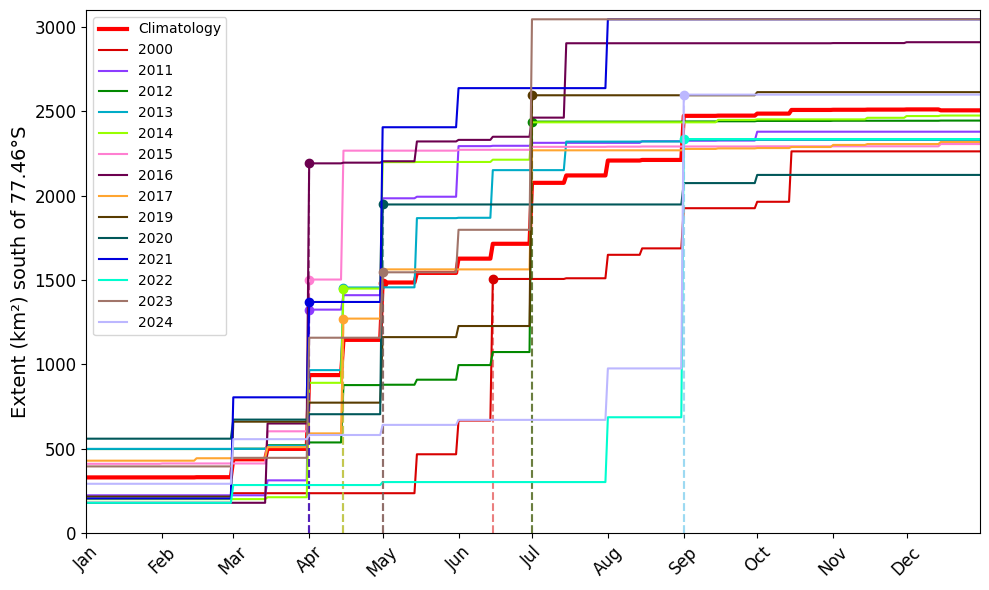

In [13]:
# format x-axis
month_starts = [f'{m}-01' for m in ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12']]
month_start_positions = [df.index.get_loc(month_start) for month_start in month_starts]
month_start_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax1 = plt.subplots(figsize=(10, 6))

clim_max = df["clim"].max()
print(clim_max)
pct_threshold = 0.5
ax1.plot(df.index, df["clim"], label="Climatology", lw=3, color='red')
add_x_pct_marker(ax1, df.index, df["clim"], clim_max, pct_threshold, color='red')
years = [2000, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2019, 2020, 2021, 2022, 2023, 2024]
cmap = cc.cm.glasbey
for i, year_idx in enumerate(years):
    col = "EX" + str(year_idx)
    color = cmap(i)
    line, = ax1.plot(df.index, df[col], label=year_idx, color=color)
    add_x_pct_marker(ax1, df.index, df[col], clim_max, pct_threshold, color=color)

ax1.set_ylabel("Extent (km²) south of 77.46°S", fontsize=14)
lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(lines1, labels1, loc="upper left")
ax1.tick_params(labelsize=12)
ax1.set_xticks(ticks=month_start_positions, labels=month_start_labels, rotation=45)
ax1.set_xlim(('01-01', '12-31'))
ax1.set_ylim((0,3100))
#ax1.set_title('all years', fontsize=18)
plt.tight_layout()

plt.savefig('../Figures/formation_timelines', bbox_inches='tight')
plt.show()

## Show any year's storminess and formation timeline

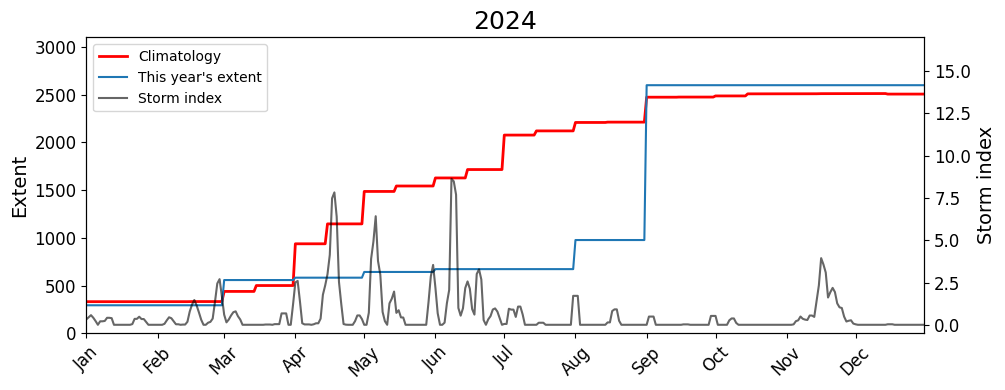

In [14]:
year = 2024

# format x-axis
month_starts = [f'{m}-01' for m in ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12']]
month_start_positions = [df.index.get_loc(month_start) for month_start in month_starts]
month_start_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(df.index, df["clim"], label="Climatology", lw=2, color='red')
ax1.plot(df.index, df["EX"+str(year)], label="This year's extent")
ax1.set_ylabel("Extent", fontsize=14)

ax2 = ax1.twinx()
ax2.plot(df.index, df["SI"+str(year)], label="Storm index", alpha=0.6, color='black')
ax2.set_ylabel("Storm index", fontsize=14)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.tick_params(labelsize=12)
ax2.tick_params(labelsize=12)
ax1.set_xticks(ticks=month_start_positions, labels=month_start_labels, rotation=45)
ax1.set_xlim(('01-01', '12-31'))
ax1.set_ylim((0,3100))
ax2.set_ylim((-0.5,17))
ax1.set_title(f"{year}", fontsize=18)
plt.tight_layout()
plt.savefig('../Figures/detail_'+str(year), bbox_inches='tight')
plt.show()

## Show each year's storminess, extent, and formation date

In [15]:
df_years = pd.DataFrame()
df_years['year'] = [2000, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2019, 2020, 2021, 2022, 2023, 2024]
df_years['winter_si'] = [0.55, 0.99, 0.91, 0.45, 1.30, 0.77, 0.37, 1.56, 1.69, 0.86, 0.55, 1.32, 0.42, 0.88]
df_years['fraser_data'] = [True, True, True, True, True, True, True, True, False, False, False, False, False, False]
df_years['formation_month'] = ['April', 'April', 'June', 'April', 'April', 'April', 'March', 'April', 'July', 'May', 'May', 'September', 'April', 'September']
df_years['formation_month_num'] = [6, 4, 7, 4, 4, 4, 4, 4, 7, 5, 4, 9, 5, 9]    # 1/2 pct_threshold
#df_years['formation_month_num'] = [7, 5, 7, 5, 5, 4, 4, 5, 7, 5, 5, 9, 6, 9]    # 2/3 pct_threshold
df_years['area'] = [2277, 2379, 2445, 2331, 2475, 2306, 2909, 2318, 2613, 2123, 3045, 2335, 3045, 2599]
df_years = df_years.sort_values(by='winter_si')
df_years

,year,winter_si,fraser_data,formation_month,formation_month_num,area
6,2016,0.37,True,March,4,2909
12,2023,0.42,False,April,5,3045
3,2013,0.45,True,April,4,2331
0,2000,0.55,True,April,6,2277
10,2021,0.55,False,May,4,3045
5,2015,0.77,True,April,4,2306
9,2020,0.86,False,May,5,2123
13,2024,0.88,False,September,9,2599
2,2012,0.91,True,June,7,2445
1,2011,0.99,True,April,4,2379


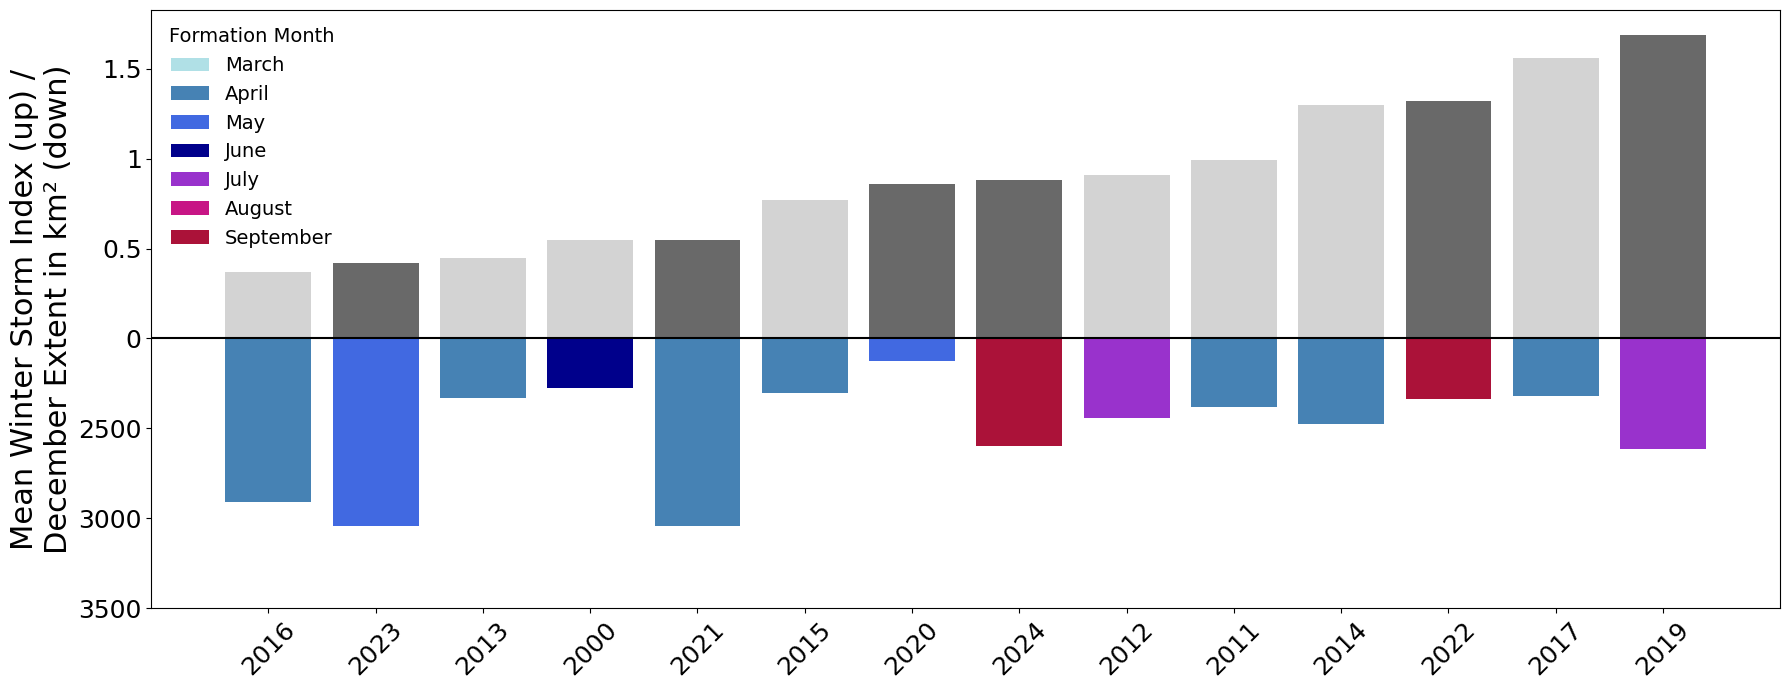

In [16]:
fig, ax = plt.subplots(figsize=(18, 7))

winter_colors = np.where(df_years["fraser_data"], "lightgray", "dimgray")
month_colors = {
    3: "powderblue",
    4: "steelblue",
    5: "royalblue",
    6: "darkblue",
    7: "darkorchid",
    8: "mediumvioletred",
    9: "xkcd:rouge"}
formation_colors = df_years["formation_month_num"].map(month_colors)

x = range(len(df_years))
ax.bar(x, df_years["winter_si"], color=winter_colors)
ax.bar(x, -0.001*(df_years["area"]-2000), color=formation_colors)

ax.axhline(0, color='k')

ax.set_xticks(x)
ax.set_xticklabels(df_years["year"], rotation=45)
ax.set_ylabel("Mean Winter Storm Index (up) /\nDecember Extent in km² (down)", fontsize=22)

# tick labels
ax.set_yticks([-1.5, -1, -0.5, 0, 0.5, 1, 1.5])
ax.set_yticklabels(["3500", "3000", "2500", "0", "0.5", "1", "1.5"])
ax.tick_params(labelsize=18)

# legend
legend_elements = [
    # winter_si
    #mpatches.Patch(facecolor="lightgray", label="2000, 2011 - 2017"),
    #mpatches.Patch(facecolor="dimgray", label="2019 - 2024"),
    # formation month
    mpatches.Patch(facecolor="powderblue", label="March"),
    mpatches.Patch(facecolor="steelblue", label="April"),
    mpatches.Patch(facecolor="royalblue", label="May"),
    mpatches.Patch(facecolor="darkblue", label="June"),
    mpatches.Patch(facecolor="darkorchid", label="July"),
    mpatches.Patch(facecolor="mediumvioletred", label="August"),
    mpatches.Patch(facecolor="xkcd:rouge", label="September"),]
ax.legend(handles=legend_elements, loc=2, frameon=False, fontsize=14, title="Formation Month", title_fontsize=14)

plt.tight_layout()
plt.savefig('../Figures/si_connection_wide', bbox_inches='tight')
plt.show()